In [1]:
import os
import json
import numpy as np
import scienceplots
import matplotlib.pyplot as plt
plt.style.use(['science', 'ieee'])

In [ ]:
def convert_and_plot(path, name):
    # 读取数据
    pred = np.load(os.path.join(path, 'pred.npy'))
    true = np.load(os.path.join(path, 'true.npy'))

    with open(os.path.join(path, 'metrics.json'), 'r', encoding='utf-8') as file:
        metric = json.load(file)
    r2 = round(metric['r2'], 4)
    
    error = pred - true  # 计算误差

    # 创建画布和主坐标系
    fig, ax = plt.subplots(figsize=(5, 4))

    # -------------------------------------
    # 1. 绘制主散点图和对角线
    # -------------------------------------
    # 计算坐标轴共同范围
    combined_min = min(np.min(true), np.min(pred))
    combined_max = max(np.max(true), np.max(pred))
    margin = (combined_max - combined_min) * 0.1  # 10%边距

    # 绘制散点图
    scatter = ax.scatter(true, pred, c=error, cmap='brg', alpha=0.7, edgecolors='w', linewidth=0.5, label='Predicted RUL')

    # 绘制理想对角线
    ax.plot([combined_min-margin, combined_max+margin], 
            [combined_min-margin, combined_max+margin], 
            'k--', lw=1.5, label='Reference RUL')

    # 设置坐标轴
    # ax.set_xlabel('True RUL (cycles)', fontsize=12)
    # ax.set_ylabel('Predicted RUL (cycles)', fontsize=12)
    ax.set_title(name)
    ax.set_xlim(combined_min - margin, combined_max + margin)
    ax.set_ylim(combined_min - margin, combined_max + margin)
    ax.set_aspect('equal')
    # ax.grid(ls='--', alpha=0.5)

    # -------------------------------------
    # 2. 添加误差分布子图（左上角）
    # -------------------------------------
    # 创建内嵌坐标系（参数：left, bottom, width, height）
    hist_ax = fig.add_axes([0.25, 0.65, 0.25, 0.2])

    # 计算直方图参数
    max_error = max(abs(error.min()), error.max())
    bins = np.linspace(-max_error, max_error, 25)

    # 绘制直方图
    n, bins, patches = hist_ax.hist(error, bins=bins, color='dodgerblue', edgecolor='white', alpha=1)

    # 设置子图样式
    hist_ax.set_xlabel('Error')
    hist_ax.set_ylabel('Frequency')
#     hist_ax.set_title('Error Distribution', fontsize=10, pad=10)
    hist_ax.tick_params(axis='both', labelsize=8)

    # -------------------------------------
    # 3. 添加图例（右下角）
    # -------------------------------------
    # 主图图例
    main_legend = ax.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02), frameon=True, fontsize=9)
    main_legend.get_frame().set_alpha(0.9)

    # -------------------------------------
    # 4. 添加 R² 值到图片右下角
    # -------------------------------------
    # 在右下角添加 R² 值
    ax.text(0.9, 0.3, f'$R^2 = {r2}$', transform=ax.transAxes, 
            fontsize=15, color='black', ha='right', va='bottom', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

    # 颜色条图例
    cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
#     cbar.set_label('Prediction Error', rotation=270, labelpad=15, fontsize=10)
    plt.savefig(f'./{name}.png')
    plt.tight_layout()
    plt.plot()

C:\Users\lxh\AppData\Local\Temp\ipykernel_8144\4258749484.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


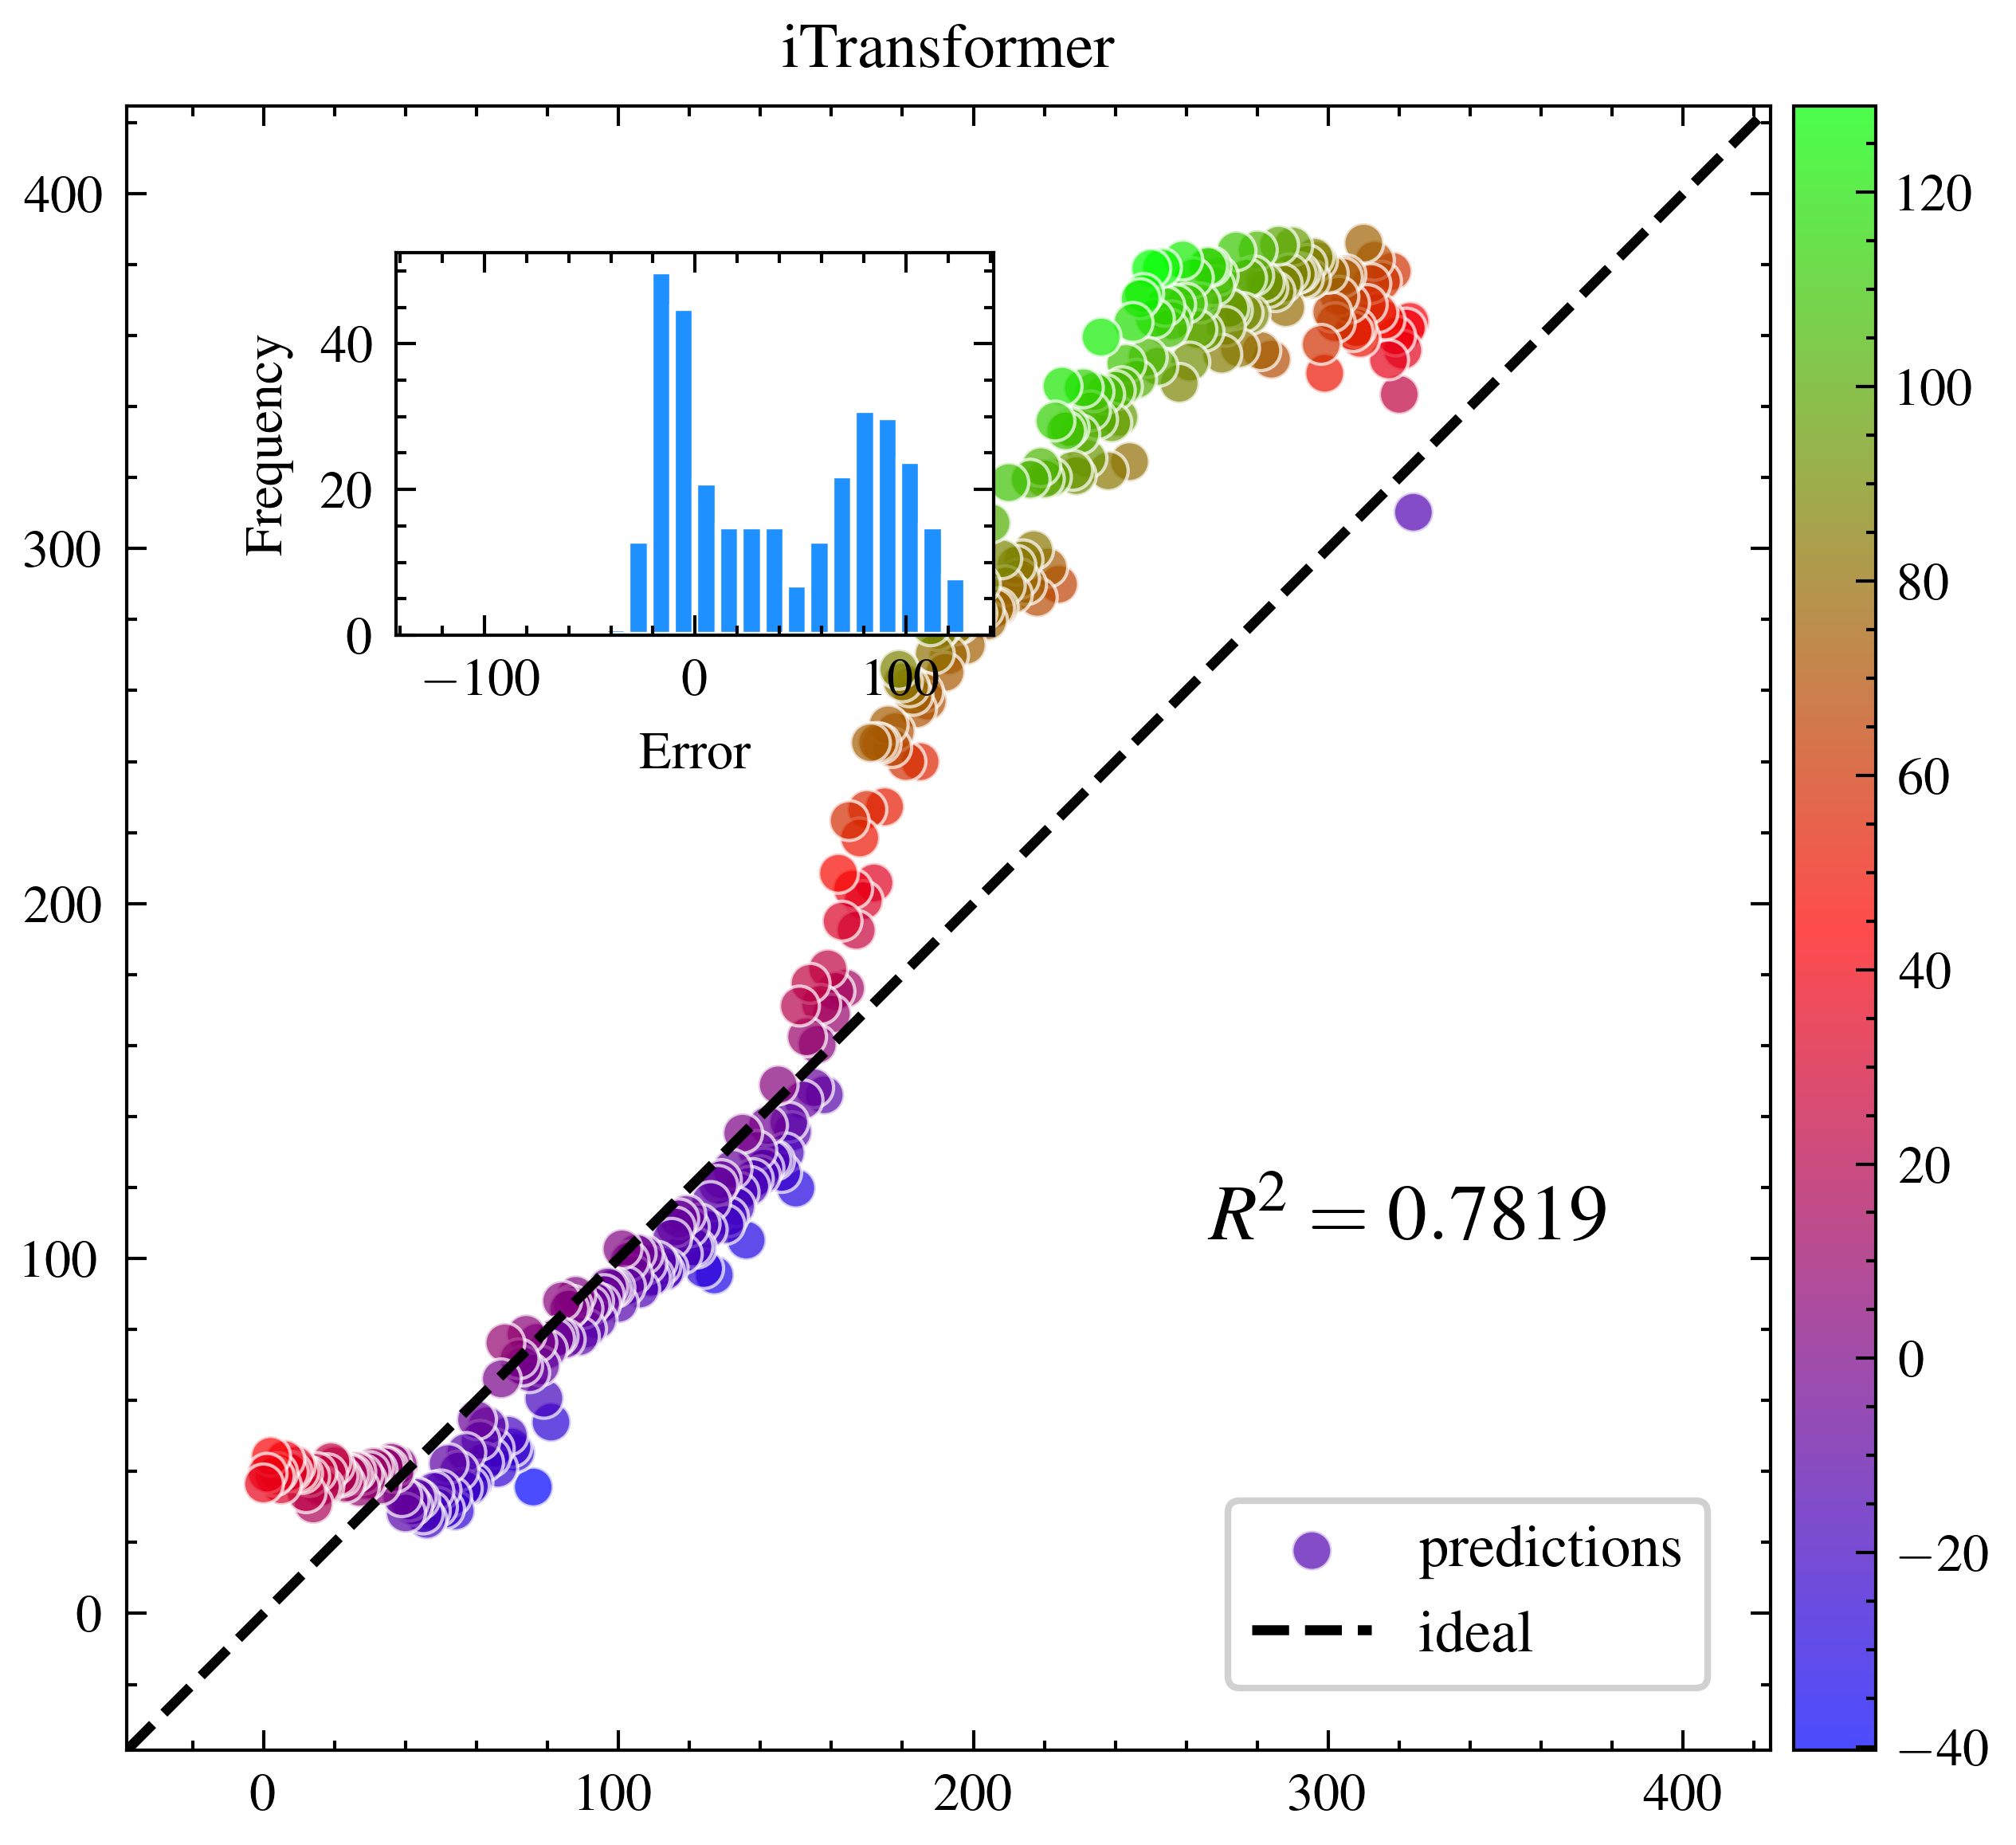

In [ ]:
models = {
    'iTransformer': '../../data/comp_res/1_iTransformer/task1_exp2024/rul_task1_iTransformer_tri_pseudo_policy1C(4%)-6C_id9_cl300_task1_exp2024_0',
    'iTransformer+': '../../data/comp_res/2_iTransformer+/task1_exp2024/rul_task1_iTransformer_tri_pseudo_policy6C(52%)-3.5C_id47_cl429_task1_exp2024_0',
    'PatchTST': '../../data/comp_res/3_PatchTST/task1_exp2024/rul_task1_PatchTST_tri_pseudo_policy1C(4%)-6C_id9_cl300_task1_exp2024_0',
    'PatchTST+': '../../data/comp_res/4_PatchTST+/task1_exp2024/rul_task1_PatchTST_tri_pseudo_policy6C(52%)-3.5C_id47_cl429_task1_exp2024_0',
    'TSMixer': '../../data/comp_res/5_TSMixer/task1_exp2024/rul_task1_TSMixer_tri_pseudo_policy1C(4%)-6C_id9_cl300_task1_exp_0',
    'TSMixer+': '../../data/comp_res/6_TSMixer+/task1_exp2024/rul_task1_TSMixer_tri_pseudo_policy6C(52%)-3.5C_id47_cl429_task1_exp2024_0',
    'PINN': '../../data/comp_res/7_PINN/RUL/task1/policy1C(4%)-6C_id9_cl300',
    'PINN+': '../../data/comp_res/8_PINN+/RUL/task1/policy1C(4%)-6C_id9_cl300',
    'DRNet': '../../data/comp_res/9_DR-Net/task1_exp2024/RUL_task1_DRNet_tri_pseudo_policy1C(4%)-6C_id9_cl300_task1_exp2024_0',
    'CRNN': '../../data/comp_res/10_CRNN/task1_exp2024/RUL_task1_CRNN_tri_pseudo_policy1C(4%)-6C_id9_cl300_task1_exp2024_0',
    'MAGNet': '../../data/comp_res/11_MAGNet/task1_exp2024/RUL_task1_Informer_tri_pseudo_policy1C(4%)-6C_id9_cl300_task1_exp2024_0',
    'bagging': '../../data/comp_res/12_bagging/task1/RUL_DeNN_bagging_tri_task1_policy1C(4%)-6C_id9_cl300',
    'fusion': '../../data/comp_res/13_fusion/task1/RUL_DeNN_fusion_tri_task1_policy1C(4%)-6C_id9_cl300',
    'voting': '../../data/comp_res/14_voting/task1/RUL_DeNN_voting_tri_task1_policy1C(4%)-6C_id9_cl300',
    'MambaLithium': '../../data/comp_res/15_MambaLithium/task1_exp2024/RUL_task1_MambaLithium_tri_pseudo_policy1C(4%)-6C_id9_cl300_task1_exp2024_0',
    'LSTM-DA': '../../data/comp_res/16_LSTM-DA/task1_exp2024/RUL_policy1C(4%)-6C_id9_cl300_lstm_mmd',
    'ConvMMD': '../../data/comp_res/17_ConvMMD/RUL/task1_exp2024/RUL_policy1C(4%)-6C_id9_cl300_lenet5_mmd',
    'DKTL': '../../data/comp_res/18_DKTL/task1_exp2024/RUL_policy1C(4%)-6C_id9_cl300_lenet5_coral',
    'DDAN': '../../data/comp_res/19_DDAN/task1_exp2024/RUL_policy1C(4%)-6C_id9_cl300_dbgru_adv',
    'OURS': '../../data/comp_res/21_ours/task1_exp2024/RUL_task1_OURS_tri_pseudo_policy1C(4%)-6C_id9_cl300_task1_exp2024_0'
}

# 遍历所有模型绘制结果
for idx, (model_name, model_dir) in enumerate(models.items()):
    try:
        convert_and_plot(model_dir, model_name)
    except Exception as e:
        print(f"Error loading {model_name}: {str(e)}")
    break